In [1]:
import os
import joblib
from IPython.display import display, Latex

from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss

import numpy as np
import matplotlib.pyplot as plt

import torch

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

tensor(900)
torch.Size([900, 10])


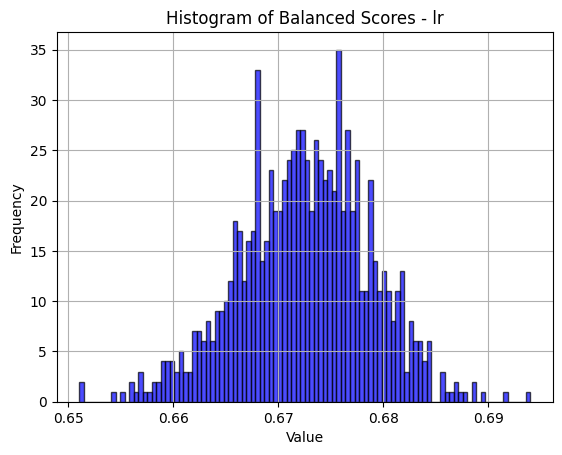

tensor(900)
torch.Size([900, 10])


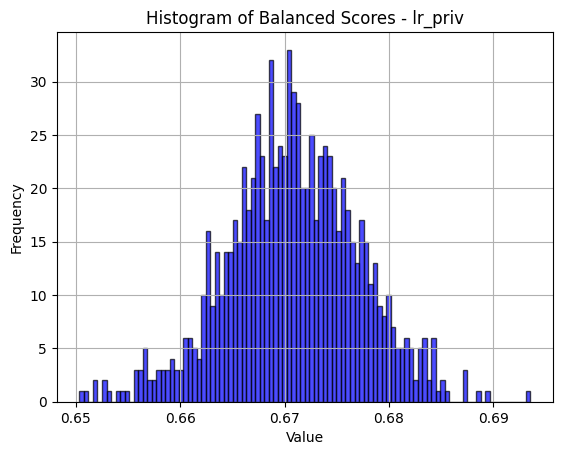

tensor(900)
torch.Size([900, 10])


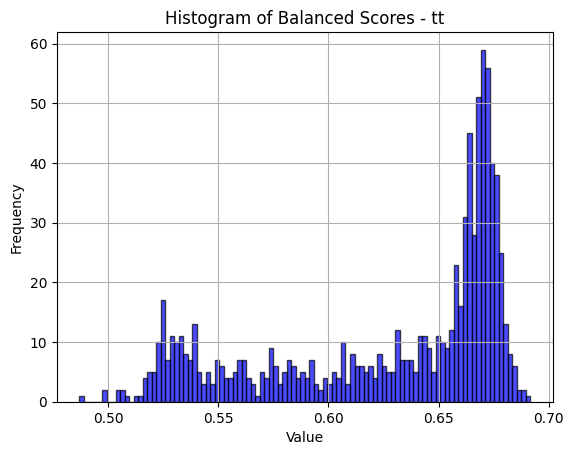

In [27]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr', 'lr_priv', 'tt']:
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    # mask = data['labels'][:, 0] == 1
    mask = (data['labels'] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    # mask = mask * (data['bal_accs'][:, 0] > 0.65)
    accs = data['bal_accs'][mask]
    aucs = data['auc_scores'][mask]
    
    print(mask.sum())
    print(accs.shape)
    
    # Plot histogram scores
    # plt.hist(accs[:, -1].numpy(), bins=100, alpha=0.7,
    #          color='blue', edgecolor='black')
    plt.hist(accs[:, 0].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - {model_name}")
    plt.grid(True)

    # Show plot
    plt.show()

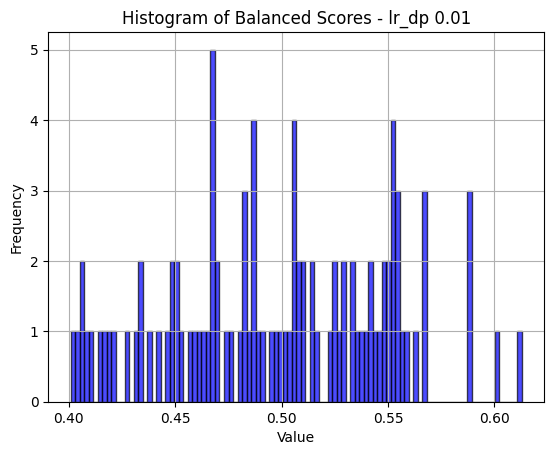

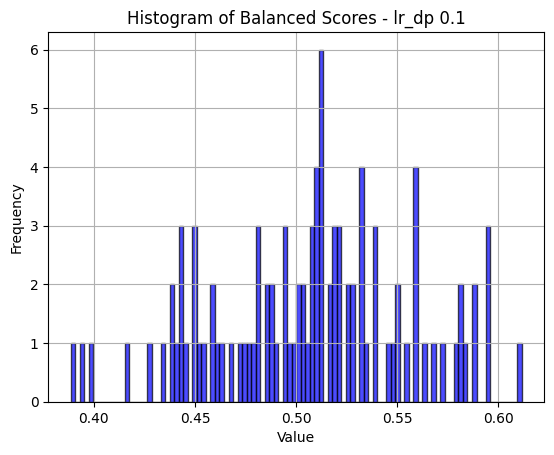

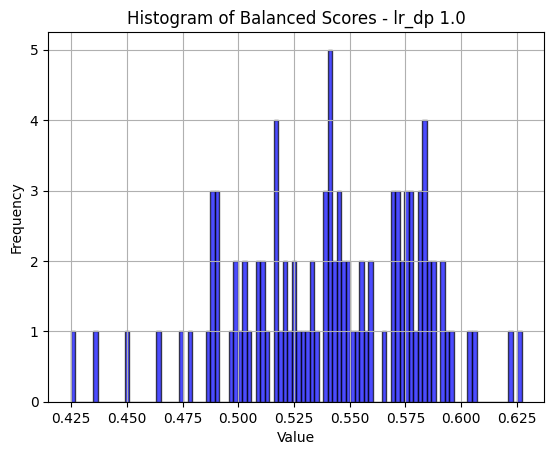

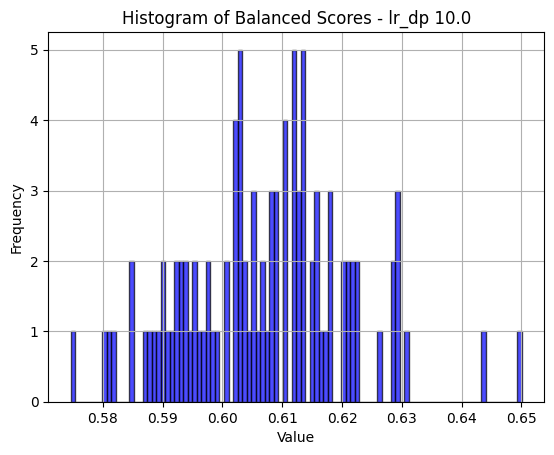

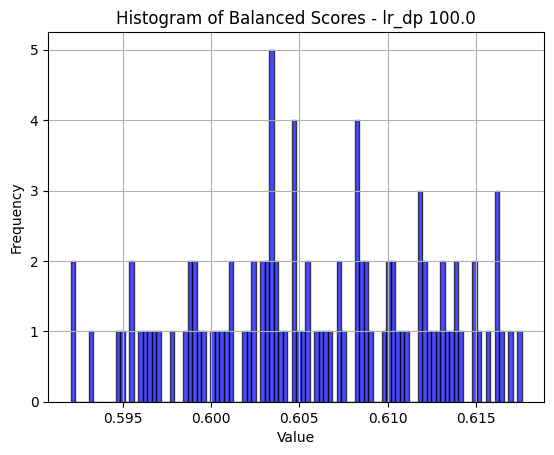

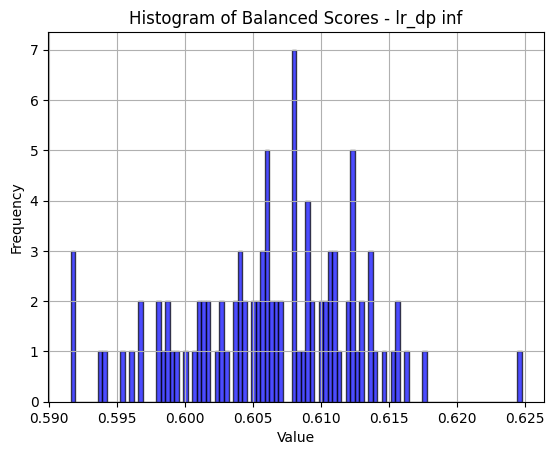

In [12]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]
for epsilon in epsilon_list:
    data_dir = os.path.join(cwd, 'results', 'datasets', 'lr_dp',
                            scaler_type, model_type, f'params_multilabel_{epsilon}.pt')
    data = torch.load(data_dir, weights_only=True)
    
    # mask = data['labels'][:, 0] == 1
    mask = (data['labels'] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    accs = data['bal_accs'][mask]
    aucs = data['auc_scores'][mask]
    
    # Plot histogram scores
    # plt.hist(accs[:, -1].numpy(), bins=100, alpha=0.7,
    #          color='blue', edgecolor='black')
    plt.hist(accs[:, 0].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - lr_dp {epsilon}")
    plt.grid(True)

    # Show plot
    plt.show()

# LLR6 vanilla

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

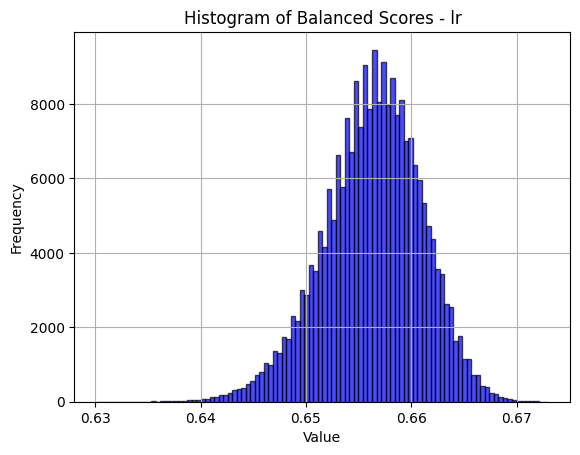

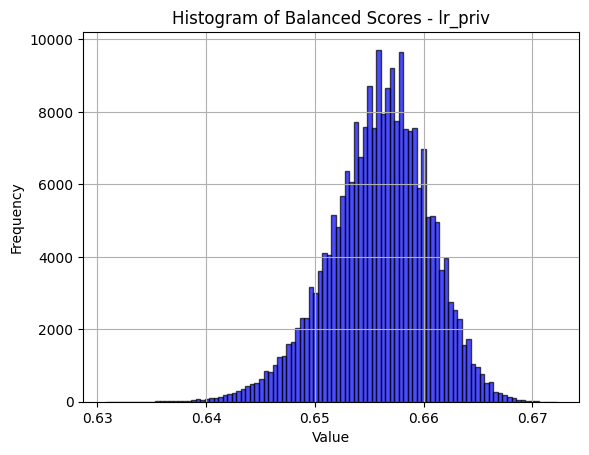

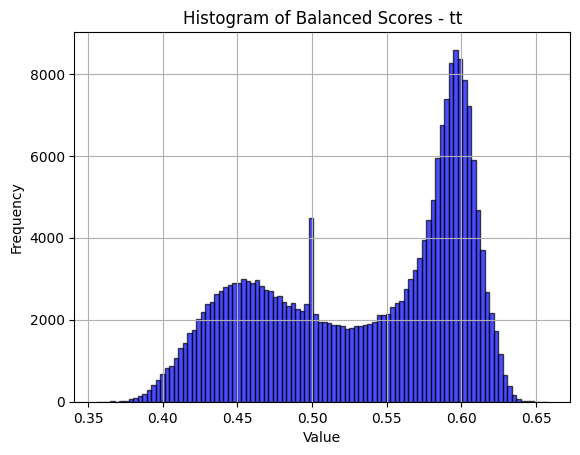

In [4]:
# vanilla
scaler_type = 'standard'
model_type = 'vanilla'

for model_name in ['lr', 'lr_priv', 'tt']:
    data_dir = os.path.join(cwd, 'results', 'datasets', model_name,
                            scaler_type, model_type, 'params_multilabel.pt')
    data = torch.load(data_dir, weights_only=True)
    
    mask = data['labels'][:, 0] == 1
    accs = data['bal_accs'][mask]
    aucs = data['auc_scores'][mask]
    
    # Plot histogram scores
    plt.hist(accs[:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - {model_name}")
    plt.grid(True)

    # Show plot
    plt.show()

### Accuracies on train/test

In [5]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [6]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [7]:
all_params[cond][200:300, :][0]

tensor([ 4.1880e-02, -7.5578e-01,  5.2582e-01, -3.2770e-02,  1.7373e-03,
        -3.3464e-01, -4.6585e-01, -4.3904e-01,  1.1167e-01,  5.7964e-01,
         1.8843e-01,  8.4085e-02, -3.0920e-02,  0.0000e+00,  5.1239e-01,
        -1.5643e-02,  0.0000e+00, -1.1611e+00,  5.2785e-01,  0.0000e+00,
         0.0000e+00, -1.9501e+00], dtype=torch.float64)

In [8]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7475, std: 0.0064
C=0.1 , l1=0.5, mean: 0.7497, std: 0.0059
C=0.1 , l1=1.0, mean: 0.7519, std: 0.0037 <--
C=1.0 , l1=0.0, mean: 0.7475, std: 0.0065
C=1.0 , l1=0.5, mean: 0.7475, std: 0.0063
C=1.0 , l1=1.0, mean: 0.7479, std: 0.0064
C=10.0, l1=0.0, mean: 0.7473, std: 0.0056
C=10.0, l1=0.5, mean: 0.7479, std: 0.0063
C=10.0, l1=1.0, mean: 0.7475, std: 0.0067


In [9]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7412, std: 0.0021
C=0.1 , l1=0.5, mean: 0.7408, std: 0.0022
C=0.1 , l1=1.0, mean: 0.7381, std: 0.0024 <--
C=1.0 , l1=0.0, mean: 0.7412, std: 0.0023
C=1.0 , l1=0.5, mean: 0.7410, std: 0.0022
C=1.0 , l1=1.0, mean: 0.7411, std: 0.0020
C=10.0, l1=0.0, mean: 0.7411, std: 0.0017
C=10.0, l1=0.5, mean: 0.7411, std: 0.0021
C=10.0, l1=1.0, mean: 0.7408, std: 0.0023


In [10]:
# Evaluate on all datasets
for i in range(len(datasets)):
    aux = all_auc_scores[cond][200:300, i]
    print(f'{datasets[i]:>16}, mean: {aux.mean().item():.4f}, '
          f'std: {aux.std().item():.4f}')

   Chowell_train, mean: 0.7381, std: 0.0024
    Chowell_test, mean: 0.7519, std: 0.0037
            MSK1, mean: 0.6949, std: 0.0054
            MSK2, mean: 0.6317, std: 0.0080
      Shim_NSCLC, mean: 0.5890, std: 0.0098
  Kato_panCancer, mean: 0.7669, std: 0.0387
   Vanguri_NSCLC, mean: 0.6636, std: 0.0038
      Ravi_NSCLC, mean: 0.7242, std: 0.0023
Pradat_panCancer, mean: 0.7046, std: 0.0291


In [11]:
# Evaluate on all datasets model trained on MSK1
cond = (all_labels == torch.tensor([0, 0, 1, 0, 0, 0, 0, 0, 0])).all(dim=1)

for i in range(len(datasets)):
    aux = all_auc_scores[cond][200:300, i]
    print(f'{datasets[i]:>16}, mean: {aux.mean().item():.4f}, '
          f'std: {aux.std().item():.4f}')

   Chowell_train, mean: 0.7109, std: 0.0091
    Chowell_test, mean: 0.7048, std: 0.0184
            MSK1, mean: 0.7113, std: 0.0066
            MSK2, mean: 0.5831, std: 0.0247
      Shim_NSCLC, mean: 0.5983, std: 0.0157
  Kato_panCancer, mean: 0.6427, std: 0.0424
   Vanguri_NSCLC, mean: 0.6571, std: 0.0090
      Ravi_NSCLC, mean: 0.7053, std: 0.0202
Pradat_panCancer, mean: 0.7001, std: 0.0281


### Accuracies on all datasets

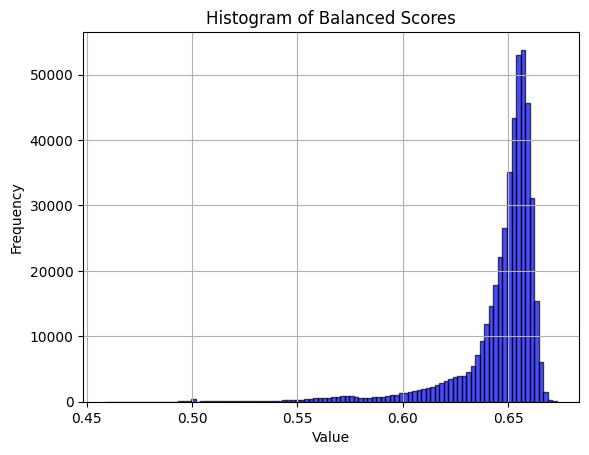

In [12]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

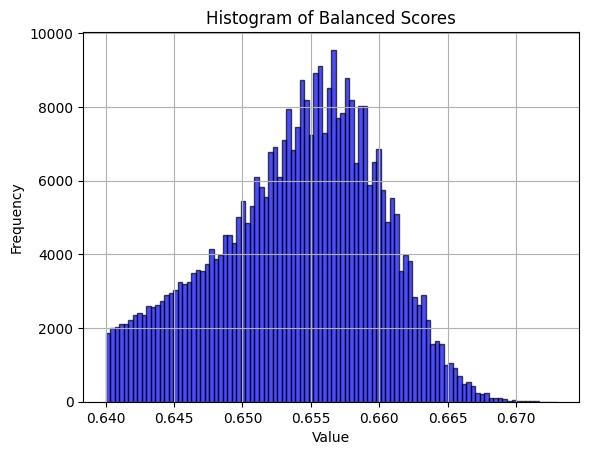

In [13]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [14]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [15]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
# mlp_bb = joblib.load(
#     os.path.join(attack_model_dir,
#                  f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
# X_test, y_test = joblib.load(
#     os.path.join(attack_model_dir,
#                  f'heldout_test_set_bb_{attack_name}.pkl'))
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_bb_{attack_name}_1.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'test_set_bb_{attack_name}_1.pkl'))

In [16]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7716
F1-score: 0.7890657043779441

Confusion Matrix for Class 0 - Chowell_train:
[[0.86434163 0.13565837]
 [0.06358394 0.93641606]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.84200527 0.15799473]
 [0.11071493 0.88928507]]

Confusion Matrix for Class 2 - MSK1:
[[0.82496118 0.17503882]
 [0.08298023 0.91701977]]

Confusion Matrix for Class 3 - MSK2:
[[0.62628028 0.37371972]
 [0.25159151 0.74840849]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.69735955 0.30264045]
 [0.277178   0.722822  ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.59275036 0.40724964]
 [0.45600171 0.54399829]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.63736723 0.36263277]
 [0.26018417 0.73981583]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.84518027 0.15481973]
 [0.17751541 0.82248459]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.76502962 0.23497038]
 [0.16423579 0.83576421]]


              precision    recall  f1-score   support

           0       0.92      0.94   

### Strong (AUC scores)

In [4]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
# mlp_bb = joblib.load(
#     os.path.join(attack_model_dir,
#                  f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
# X_test, y_test = joblib.load(
#     os.path.join(attack_model_dir,
#                  f'heldout_test_set_bb_{attack_name}.pkl'))
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_bb_{attack_name}_1.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'test_set_bb_{attack_name}_1.pkl'))

In [5]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9047
F1-score: 0.9118839449103486

Confusion Matrix for Class 0 - Chowell_train:
[[0.9905494  0.0094506 ]
 [0.00180611 0.99819389]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.94726842 0.05273158]
 [0.00938798 0.99061202]]

Confusion Matrix for Class 2 - MSK1:
[[0.94866205 0.05133795]
 [0.01792843 0.98207157]]

Confusion Matrix for Class 3 - MSK2:
[[0.95433316 0.04566684]
 [0.00750663 0.99249337]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.85317043 0.14682957]
 [0.14794822 0.85205178]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.60870391 0.39129609]
 [0.20653567 0.79346433]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.78347412 0.21652588]
 [0.19109308 0.80890692]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.95231619 0.04768381]
 [0.06548428 0.93451572]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.94227781 0.05772219]
 [0.0635423  0.9364577 ]]


              precision    recall  f1-score   support

           0       0.99      1.00   

## White-box attack ensemble

In [11]:
aux_dir = 'attack_models_old' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [12]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.9168


In [13]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.9226125396785654

Confusion Matrix for Class 0 - Chowell_train:
[[9.97990056e-01 2.00994393e-03]
 [5.22261392e-04 9.99477739e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9912744  0.0087256 ]
 [0.00560798 0.99439202]]

Confusion Matrix for Class 2 - MSK1:
[[0.96523548 0.03476452]
 [0.01581485 0.98418515]]

Confusion Matrix for Class 3 - MSK2:
[[0.98783034 0.01216966]
 [0.01255572 0.98744428]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.85438734 0.14561266]
 [0.14470588 0.85529412]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.79652316 0.20347684]
 [0.26468078 0.73531922]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.69631182 0.30368818]
 [0.12831296 0.87168704]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91287278 0.08712722]
 [0.02723958 0.97276042]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.95472338 0.04527662]
 [0.06629067 0.93370933]]


              precision    recall  f1-score   support

           0       1.00      1.00    

### Evaluate LORIS

In [14]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [15]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [16]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 1.0000
    Chowell_test: 0.0097
            MSK1: 0.0333
            MSK2: 0.1326
      Shim_NSCLC: 0.0667
  Kato_panCancer: 0.2923
   Vanguri_NSCLC: 0.5164
      Ravi_NSCLC: 0.0064
Pradat_panCancer: 0.0230


### Check other models

In [64]:
aux_datasets = [0, 1]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([167, 22])


tensor([[ 0.0490, -0.9279,  0.7556, -0.0495,  0.0101, -0.7899, -0.1523, -0.6680,
          0.2718,  0.9749,  0.0231,  0.1244, -0.1548, -0.0752,  0.3059,  0.0439,
         -0.6481, -1.5618,  0.8494,  0.2825,  0.2632, -3.2196]],
       dtype=torch.float64)

In [65]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.9999
            MSK1: 0.0201
            MSK2: 0.0318
      Shim_NSCLC: 0.0443
  Kato_panCancer: 0.4572
   Vanguri_NSCLC: 0.4481
      Ravi_NSCLC: 0.0242
Pradat_panCancer: 0.4984


# LLR6 average

## Datasets

In [24]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [25]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = True      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [26]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [27]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [28]:
all_params[cond][200:300, :][0]

tensor([ 3.5625e-02, -8.6805e-01,  5.1487e-01, -3.0641e-02,  4.4756e-03,
        -2.9795e-01, -2.8235e-01, -7.2376e-02,  2.7089e-03,  4.8952e-01,
         2.0883e-01,  5.7606e-02, -1.2260e-01, -8.6673e-03,  9.3944e-02,
         7.2984e-04, -6.2564e-02, -9.0208e-01,  4.9290e-01,  5.7316e-02,
        -1.0378e-02, -1.9780e+00], dtype=torch.float64)

In [29]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7508, std: 0.0003
C=0.1 , l1=0.5, mean: 0.7527, std: 0.0003
C=0.1 , l1=1.0, mean: 0.7551, std: 0.0005 <--
C=1.0 , l1=0.0, mean: 0.7490, std: 0.0004
C=1.0 , l1=0.5, mean: 0.7496, std: 0.0004
C=1.0 , l1=1.0, mean: 0.7504, std: 0.0004
C=10.0, l1=0.0, mean: 0.7478, std: 0.0005
C=10.0, l1=0.5, mean: 0.7480, std: 0.0005
C=10.0, l1=1.0, mean: 0.7481, std: 0.0006


In [30]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7442, std: 0.0001
C=0.1 , l1=0.5, mean: 0.7440, std: 0.0001
C=0.1 , l1=1.0, mean: 0.7406, std: 0.0002 <--
C=1.0 , l1=0.0, mean: 0.7437, std: 0.0001
C=1.0 , l1=0.5, mean: 0.7442, std: 0.0001
C=1.0 , l1=1.0, mean: 0.7443, std: 0.0001
C=10.0, l1=0.0, mean: 0.7433, std: 0.0001
C=10.0, l1=0.5, mean: 0.7434, std: 0.0001
C=10.0, l1=1.0, mean: 0.7434, std: 0.0001


### Accuracies on all datasets

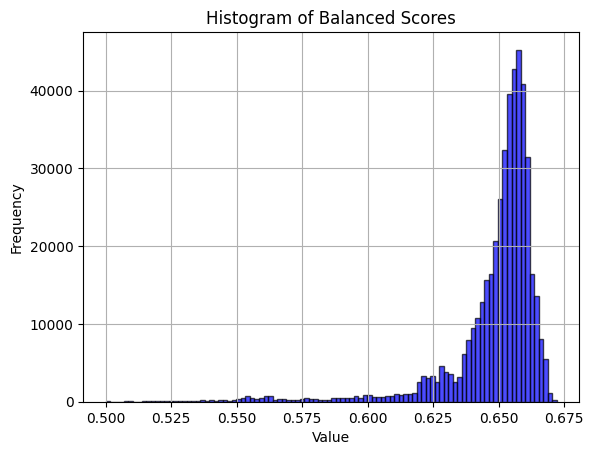

In [31]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

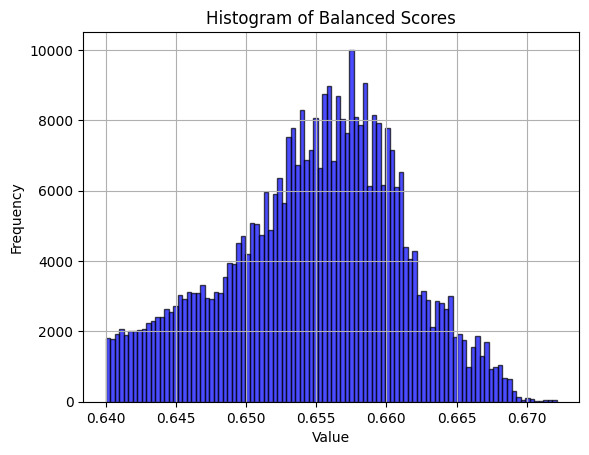

In [32]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [33]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [34]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [35]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8175
F1-score: 0.8332689553689908

Confusion Matrix for Class 0 - Chowell_train:
[[0.93080472 0.06919528]
 [0.00223757 0.99776243]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.94874187 0.05125813]
 [0.04042397 0.95957603]]

Confusion Matrix for Class 2 - MSK1:
[[0.95107955 0.04892045]
 [0.04716562 0.95283438]]

Confusion Matrix for Class 3 - MSK2:
[[0.38524373 0.61475627]
 [0.01641293 0.98358707]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74722395 0.25277605]
 [0.19698222 0.80301778]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.55474318 0.44525682]
 [0.2707202  0.7292798 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.86935987 0.13064013]
 [0.53762792 0.46237208]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.81524231 0.18475769]
 [0.06794134 0.93205866]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.80828539 0.19171461]
 [0.14068112 0.85931888]]


              precision    recall  f1-score   support

           0       0.96      1.00   

### Strong (AUC scores)

In [36]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [37]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8971
F1-score: 0.9062276381422194

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.99315729e-01 6.84271096e-04]
 [3.99139632e-04 9.99600860e-01]]

Confusion Matrix for Class 2 - MSK1:
[[9.98492972e-01 1.50702797e-03]
 [1.40373862e-04 9.99859626e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.71216782 0.28783218]
 [0.23878408 0.76121592]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.98344749 0.01655251]
 [0.01147168 0.98852832]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.57988586 0.42011414]
 [0.1170682  0.8829318 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.51874483 0.48125517]
 [0.04432878 0.95567122]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.94482349 0.05517651]
 [0.11526875 0.88473125]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.99388825 0.00611175]
 [0.07327688 0.92672312]]


              precision    recall  f1-score   support

           0       1.00      1.00   

## White-box attack ensemble

In [38]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [39]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 1.0000


In [40]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.9999851119379249

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[1.00000000e+00 0.00000000e+00]
 [5.16742456e-05 9.99948326e-01]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[9.99894801e-01 1.05199485e-04]
 [5.09878904e-05 9.99949012e-01]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[9.99973317e-01 2.66830323e-05]
 [2.51439491e-05 9.99974856e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1.00000000e+00 0.00000000e+00]
 [2.48960590e-05 9.99975104e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[1. 0.]
 [0. 1.]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46032
           1       1.00      1.00      1.00     45097
           2       1.00      1.00      1.

### Evaluate LORIS

In [41]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [42]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [43]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 1.0000
    Chowell_test: 0.0000
            MSK1: 0.0000
            MSK2: 0.0000
      Shim_NSCLC: 0.0000
  Kato_panCancer: 0.0000
   Vanguri_NSCLC: 0.0004
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0000


### Check other models

In [44]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([186, 22])


tensor([[ 0.0486, -0.9313,  0.5371, -0.0531,  0.0129, -0.7227, -1.0141, -0.4899,
         -0.1377,  0.8466,  0.3749,  0.2779, -0.5704, -0.2109,  0.4417,  0.0536,
         -0.4198, -3.8424,  0.8058,  0.3673, -0.0631, -2.5046]],
       dtype=torch.float64)

In [45]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.0000
            MSK1: 0.0000
            MSK2: 0.0000
      Shim_NSCLC: 1.0000
  Kato_panCancer: 1.0000
   Vanguri_NSCLC: 0.0000
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0000


# TT vanilla

## Datasets

In [3]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [ ]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [48]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [49]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [50]:
all_params[cond][200:300, :][0]

tensor([ 1.6946e+00,  1.3897e-01,  1.8090e+00,  2.4309e+00, -1.1462e-01,
        -7.4934e-02, -6.5371e-02, -6.3587e-02,  8.7248e-02,  5.7632e-02,
         4.8910e-02,  4.7591e-02, -1.0352e+00,  1.1717e+01, -7.9453e-01,
         2.3362e+00,  2.2588e+00, -1.5963e+01,  7.3965e-01, -2.1124e+00,
         7.0105e-01, -1.0423e+00,  6.3817e-03, -1.5915e-02,  1.2776e-01,
        -1.0240e-01,  2.1868e-03, -5.3087e-03, -2.2441e+00, -2.8409e+00,
         4.0136e-03,  2.7503e-03,  2.2325e-01, -3.9239e-01,  1.6607e-03,
         1.1590e-03, -5.0670e+00,  1.5441e+00,  8.8521e-01, -5.6911e-01,
         4.2950e+00, -3.0732e-01, -1.2593e+00,  8.0018e-01,  9.1174e-01,
        -2.6359e-01, -6.5482e-01, -6.6357e-01, -8.0871e-01, -2.6945e+00,
        -9.7915e-01, -9.8306e-01, -4.0132e-01,  3.9712e-01, -3.5401e-02,
         1.8187e-03,  4.6112e-01, -3.9474e-01,  3.2194e-02, -4.3277e-04,
        -5.8330e+00,  7.6013e+00,  2.5788e-02, -3.9778e-02, -6.5520e+00,
         9.3930e+00, -9.2603e-02,  1.1303e-01,  1.8

In [51]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7465, std: 0.0056
C=0.1 , l1=0.5, mean: 0.7487, std: 0.0052
C=0.1 , l1=1.0, mean: 0.7510, std: 0.0036 <--
C=1.0 , l1=0.0, mean: 0.7461, std: 0.0054
C=1.0 , l1=0.5, mean: 0.7465, std: 0.0054
C=1.0 , l1=1.0, mean: 0.7468, std: 0.0053
C=10.0, l1=0.0, mean: 0.7459, std: 0.0052
C=10.0, l1=0.5, mean: 0.7464, std: 0.0054
C=10.0, l1=1.0, mean: 0.7462, std: 0.0059


In [52]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7402, std: 0.0019
C=0.1 , l1=0.5, mean: 0.7399, std: 0.0020
C=0.1 , l1=1.0, mean: 0.7376, std: 0.0023 <--
C=1.0 , l1=0.0, mean: 0.7397, std: 0.0022
C=1.0 , l1=0.5, mean: 0.7395, std: 0.0019
C=1.0 , l1=1.0, mean: 0.7397, std: 0.0019
C=10.0, l1=0.0, mean: 0.7393, std: 0.0018
C=10.0, l1=0.5, mean: 0.7396, std: 0.0019
C=10.0, l1=1.0, mean: 0.7394, std: 0.0022


### Accuracies on all datasets

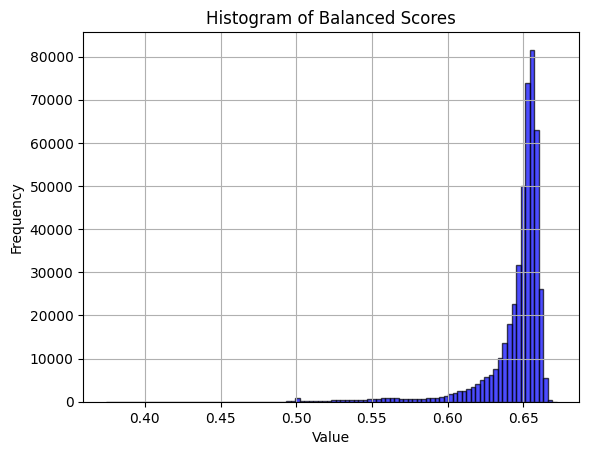

In [53]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

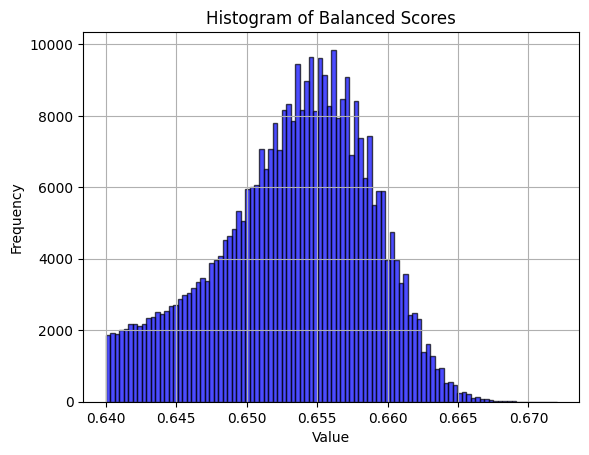

In [54]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [55]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [56]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [57]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7406
F1-score: 0.7673626083959095

Confusion Matrix for Class 0 - Chowell_train:
[[0.75420645 0.24579355]
 [0.0547373  0.9452627 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.73787858 0.26212142]
 [0.08213608 0.91786392]]

Confusion Matrix for Class 2 - MSK1:
[[0.68604442 0.31395558]
 [0.17879645 0.82120355]]

Confusion Matrix for Class 3 - MSK2:
[[0.76158468 0.23841532]
 [0.15261195 0.84738805]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.64859383 0.35140617]
 [0.31022074 0.68977926]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.51218441 0.48781559]
 [0.36247318 0.63752682]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.60927282 0.39072718]
 [0.33570562 0.66429438]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.70559761 0.29440239]
 [0.14950114 0.85049886]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.65999842 0.34000158]
 [0.22043596 0.77956404]]


              precision    recall  f1-score   support

           0       0.86      0.95   

### Strong (AUC scores)

In [58]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [ ]:
attack_model_dir = os.path.join(cwd, 'results', 'attacks', 'bb', 'tt',
                                'standard', 'vanilla')
mlp_bb = joblib.load(
    os.path.join(attack_model_dir, 'mlp_bb_weak_1.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'test_set_bb_weak_1.pkl'))

In [6]:
attack_model_dir = os.path.join(cwd, 'results', 'attacks', 'bb', 'tt',
                                'standard', 'vanilla')
mlp_bb = joblib.load(
    os.path.join(attack_model_dir, 'mlp_bb_strong_1.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'test_set_bb_strong_1.pkl'))

In [7]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7399
F1-score: 0.7383705669622025

Confusion Matrix for Class 0 - Chowell_train:
[[0.901984   0.098016  ]
 [0.08275639 0.91724361]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.93689236 0.06310764]
 [0.17819807 0.82180193]]

Confusion Matrix for Class 2 - MSK1:
[[0.813876   0.186124  ]
 [0.18217938 0.81782062]]

Confusion Matrix for Class 3 - MSK2:
[[0.88921675 0.11078325]
 [0.19934626 0.80065374]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.5990993  0.4009007 ]
 [0.37711406 0.62288594]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.57897137 0.42102863]
 [0.36388175 0.63611825]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.72482507 0.27517493]
 [0.58082764 0.41917236]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.49370815 0.50629185]
 [0.19162313 0.80837687]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.79118284 0.20881716]
 [0.25618906 0.74381094]]


              precision    recall  f1-score   support

           0       0.90      0.92   

## White-box attack ensemble

In [4]:
# aux_dir = 'attack_models' if og_model else 'attack_tt_models'
# attack_model_dir = os.path.join(cwd, aux_dir, model_name,
#                                 scaler_type, model_type)
# X_test, y_test = joblib.load(os.path.join(attack_model_dir,
#                                           'heldout_test_set_wb.pkl'))
aux_dir = 'attack_models' if og_model else 'attack_tt_lr_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'test_set_wb_1.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_wb_fold_{fold}_1.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [5]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.9177


In [6]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.8705416116248349

Confusion Matrix for Class 0 - Chowell_train:
[[0.99603175 0.00396825]
 [0.04       0.96      ]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[0.99774266 0.00225734]
 [0.04651163 0.95348837]]

Confusion Matrix for Class 3 - MSK2:
[[0.95481928 0.04518072]
 [0.14213198 0.85786802]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.61261261 0.38738739]
 [0.10749186 0.89250814]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.97326203 0.02673797]
 [0.30322581 0.69677419]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.624      0.376     ]
 [0.11138614 0.88861386]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.90397351 0.09602649]
 [0.14096916 0.85903084]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.98430493 0.01569507]
 [0.06024096 0.93975904]]


              precision    recall  f1-score   support

           0       0.92      0.96      0.94        25
           1       1.00      1.

### Evaluate models

In [63]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [64]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([178, 168])


tensor([[ 2.5768e-01, -7.0584e-01, -5.0413e-01,  6.5383e-01,  5.6709e-02,
          5.0624e-01,  2.9223e-01,  9.7227e-01,  4.7646e-02,  4.0356e-01,
          2.2661e-01,  7.5383e-01, -2.2694e+00, -4.7113e+00,  1.8152e+00,
         -1.2321e+00,  1.2916e+00,  9.3122e-01, -5.8306e-01,  4.0782e-01,
          1.6450e+00,  8.9259e-01,  2.7936e-02,  1.2152e-02,  1.0371e+00,
          6.8056e-01,  3.4961e-02,  1.5552e-02, -5.7549e+00, -9.5132e-01,
         -1.3321e-02,  3.8573e-04,  9.4195e+00,  2.0827e+00,  3.3018e-02,
         -4.9556e-04,  4.1528e-01, -6.8761e-02, -2.2857e-02, -6.9633e-03,
         -2.1673e+00, -2.4593e+00, -5.2249e-01,  1.5282e-01, -1.6725e+00,
          1.3322e+00, -2.0156e-02, -2.1391e-03,  1.2828e+00,  3.7885e-01,
         -3.1420e-01,  2.0564e-01,  4.1334e-01, -7.1336e-02, -4.5105e-02,
          5.2461e-02,  2.9144e-01,  2.9074e-01, -6.1761e-02,  6.7974e-02,
          2.1277e-01, -9.5508e-01, -1.9747e-02,  8.3750e-02, -6.4821e-01,
          2.7039e+00, -2.1092e-02,  8.

In [65]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 0.6254
    Chowell_test: 0.5979
            MSK1: 0.5468
            MSK2: 0.5045
      Shim_NSCLC: 0.5004
  Kato_panCancer: 0.5039
   Vanguri_NSCLC: 0.5158
      Ravi_NSCLC: 0.5186
Pradat_panCancer: 0.4872


# TT average

## Datasets

In [66]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [68]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [69]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [70]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [71]:
all_params[cond][200:300, :][0]

tensor([ 9.2813e-01, -9.4501e-01,  9.0738e-01, -1.8899e-01,  2.8749e-02,
        -2.7890e-02,  5.6894e-02, -5.0047e-02,  1.0291e-01, -1.0297e-01,
         2.6719e-01, -2.3507e-01, -1.2271e+01,  6.0627e+00, -6.5571e+00,
         2.0036e+00, -1.2813e+01,  6.5351e+00, -7.5311e+00,  2.3029e+00,
        -9.2488e+00, -3.2840e+00, -7.5177e-02,  1.4874e-02, -2.6163e+01,
        -1.1164e+01, -2.4325e-01,  4.5140e-02,  2.1902e+00,  1.1985e+00,
        -1.1865e-03, -6.7874e-04, -2.3331e+00, -1.4474e+00, -5.5852e-03,
        -3.0873e-03,  9.6458e-01, -2.3649e-01,  4.7235e-01,  2.4560e-01,
        -1.1372e+00,  7.3299e-01, -8.5660e-01, -4.4429e-01,  1.0364e+00,
        -7.7672e-01,  2.3477e-01, -1.9036e-01, -5.4085e-01,  3.1619e-01,
        -4.7312e-01,  3.8328e-01, -4.0933e+00, -1.3000e+01, -8.0874e-01,
        -1.6813e-02, -3.8277e+00, -1.6027e+01, -9.9910e-01, -2.1955e-02,
         3.4608e+00, -1.1022e+00,  3.3045e-05,  2.6485e-05, -3.4745e-01,
         9.6707e-01, -8.0348e-03,  2.5045e-03, -2.4

In [72]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7479, std: 0.0011
C=0.1 , l1=0.5, mean: 0.7516, std: 0.0006
C=0.1 , l1=1.0, mean: 0.7535, std: 0.0003 <--
C=1.0 , l1=0.0, mean: 0.7456, std: 0.0008
C=1.0 , l1=0.5, mean: 0.7466, std: 0.0009
C=1.0 , l1=1.0, mean: 0.7475, std: 0.0007
C=10.0, l1=0.0, mean: 0.7435, std: 0.0009
C=10.0, l1=0.5, mean: 0.7442, std: 0.0009
C=10.0, l1=1.0, mean: 0.7442, std: 0.0011


In [73]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7421, std: 0.0004
C=0.1 , l1=0.5, mean: 0.7421, std: 0.0003
C=0.1 , l1=1.0, mean: 0.7399, std: 0.0003 <--
C=1.0 , l1=0.0, mean: 0.7408, std: 0.0003
C=1.0 , l1=0.5, mean: 0.7412, std: 0.0004
C=1.0 , l1=1.0, mean: 0.7414, std: 0.0003
C=10.0, l1=0.0, mean: 0.7403, std: 0.0003
C=10.0, l1=0.5, mean: 0.7403, std: 0.0003
C=10.0, l1=1.0, mean: 0.7405, std: 0.0003


### Accuracies on all datasets

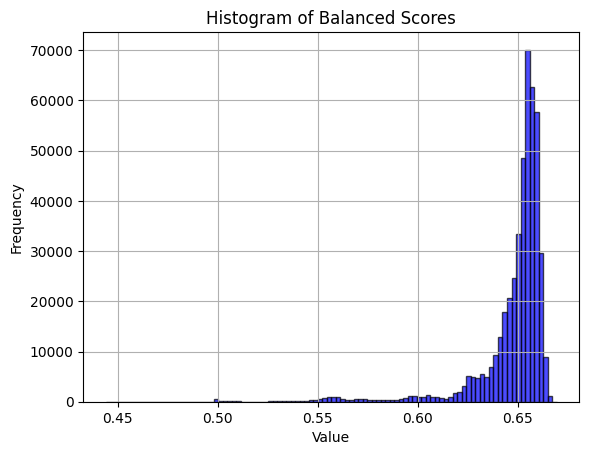

In [74]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

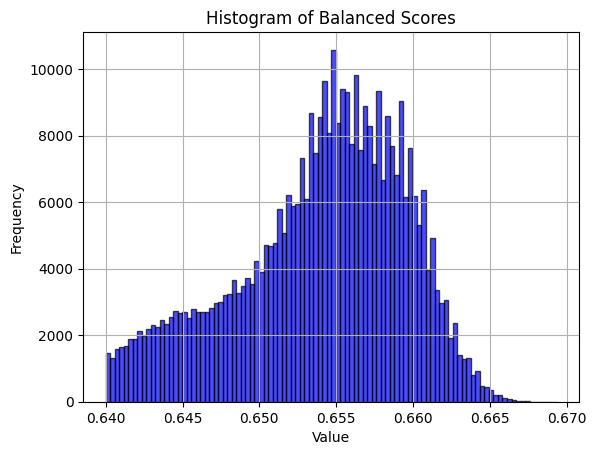

In [75]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [76]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [77]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [78]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8030
F1-score: 0.8118684230293842

Confusion Matrix for Class 0 - Chowell_train:
[[0.9395113  0.0604887 ]
 [0.05608026 0.94391974]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.83437033 0.16562967]
 [0.02594039 0.97405961]]

Confusion Matrix for Class 2 - MSK1:
[[0.8246455  0.1753545 ]
 [0.19462741 0.80537259]]

Confusion Matrix for Class 3 - MSK2:
[[0.89704954 0.10295046]
 [0.13769467 0.86230533]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74432412 0.25567588]
 [0.30100091 0.69899909]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.72946962 0.27053038]
 [0.5258184  0.4741816 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.46552723 0.53447277]
 [0.14630832 0.85369168]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91317676 0.08682324]
 [0.1627824  0.8372176 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.89276413 0.10723587]
 [0.26247924 0.73752076]]


              precision    recall  f1-score   support

           0       0.96      0.94   

### Strong (AUC scores)

In [79]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [80]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8846
F1-score: 0.892086427114221

Confusion Matrix for Class 0 - Chowell_train:
[[9.98236665e-01 1.76333522e-03]
 [2.61142061e-04 9.99738858e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.97417870e-01 2.58213041e-03]
 [7.90062766e-04 9.99209937e-01]]

Confusion Matrix for Class 2 - MSK1:
[[0.83811236 0.16188764]
 [0.02655821 0.97344179]]

Confusion Matrix for Class 3 - MSK2:
[[0.86885979 0.13114021]
 [0.09777733 0.90222267]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.95770162 0.04229838]
 [0.10149487 0.89850513]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63065029 0.36934971]
 [0.21148661 0.78851339]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.66741283 0.33258717]
 [0.32631235 0.67368765]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.88917178 0.11082822]
 [0.05579071 0.94420929]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96285043 0.03714957]
 [0.08696555 0.91303445]]


              precision    recall  f1-score   support

     

## White-box attack ensemble

In [81]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [82]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.5303


In [83]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.6403194600625649

Confusion Matrix for Class 0 - Chowell_train:
[[6.29762580e-05 9.99937024e-01]
 [4.35236769e-05 9.99956476e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.33300149e-05 9.99906670e-01]
 [2.19461879e-05 9.99978054e-01]]

Confusion Matrix for Class 2 - MSK1:
[[6.27692659e-04 9.99372307e-01]
 [1.64084292e-04 9.99835916e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.00139371 0.99860629]
 [0.00128522 0.99871478]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.99704421 0.00295579]
 [0.99724425 0.00275575]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.00394436 0.99605564]
 [0.00418336 0.99581664]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[1.07974297e-03 9.98920257e-01]
 [9.56263526e-04 9.99043736e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[7.79382729e-04 9.99220617e-01]
 [6.88459381e-04 9.99311541e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.99749783 0.00250217]
 [0.99774284 0.00225716]]


              precision    r

### Evaluate models

In [84]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [85]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([178, 168])


tensor([[ 2.6340e-01,  2.4215e-01, -5.7545e-01,  7.9972e-01,  2.2903e-01,
          8.8114e-01,  6.8059e-01,  2.6022e-01,  1.5080e-01,  6.2786e-01,
          4.8643e-01,  1.8649e-01, -7.6003e-01, -9.7035e-01, -5.3214e-02,
         -8.6947e-02,  2.5868e-01,  3.9880e-02,  2.2625e-01,  3.3909e-01,
         -6.7285e-01, -1.7267e+00, -5.3881e-02, -3.2387e-03,  7.8392e-01,
          1.2001e+00,  3.6746e-02,  1.5840e-03, -2.0753e+00, -1.8122e+00,
          2.0925e-04,  4.7431e-05, -1.1094e-01, -3.1273e-01,  1.5783e-02,
          1.3991e-02, -1.5536e+00, -6.9206e-01, -2.7923e-01, -2.3164e+00,
          1.8603e+00,  1.6392e+00,  3.0605e-01,  2.5786e+00,  2.2538e+00,
         -1.7009e+00,  5.2531e-01,  1.7316e+00,  3.2270e-04,  1.1376e+00,
         -9.7165e-02, -2.7499e-01, -8.6615e-01, -6.4047e-01,  3.0533e-02,
         -3.2790e-01,  3.3995e-01, -7.1282e-01, -3.5741e-03,  1.1577e-01,
          2.2320e-01, -8.8045e-01,  1.4888e-01, -1.3924e-03,  1.9643e+00,
         -8.6633e-02,  1.6160e-02,  1.

In [86]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 0.5926
    Chowell_test: 0.5869
            MSK1: 0.5455
            MSK2: 0.5119
      Shim_NSCLC: 0.4976
  Kato_panCancer: 0.5080
   Vanguri_NSCLC: 0.5119
      Ravi_NSCLC: 0.5085
Pradat_panCancer: 0.4966


# LLR6 DP vanilla

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

In [3]:
model_name = 'llr6'  # 'llr6' or 'nn2'
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'dp_datasets'

all_labels = {}
all_params = {}
all_bal_accs = {}
all_auc_scores = {}

for epsilon in epsilon_list:
    dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                               f'params_multilabel_{epsilon}.pt')

    all_labels_eps, all_params_eps, all_bal_accs_eps, all_auc_scores_eps = \
        torch.load(dataset_dir, weights_only=True)
    
    all_labels[epsilon] = all_labels_eps
    all_params[epsilon] = all_params_eps
    all_bal_accs[epsilon] = all_bal_accs_eps
    all_auc_scores[epsilon] = all_auc_scores_eps

### Accuracies on train/test

In [4]:
# Evaluate on Chowell_test
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 1]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [5]:
# Evaluate on Chowell_train
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 0]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Accuracies on all datasets

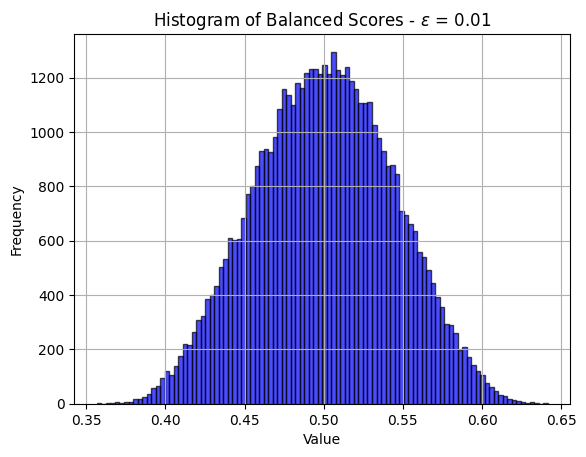

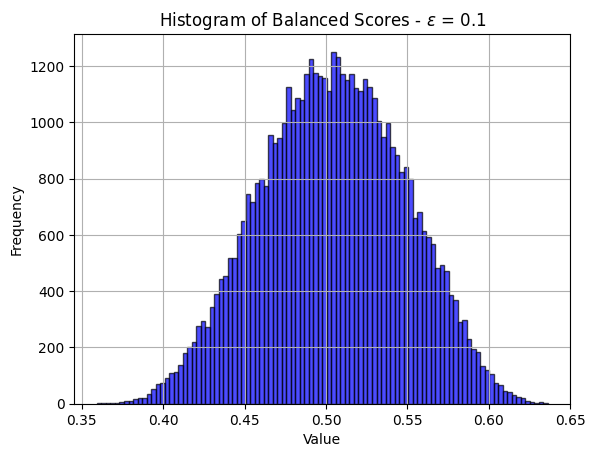

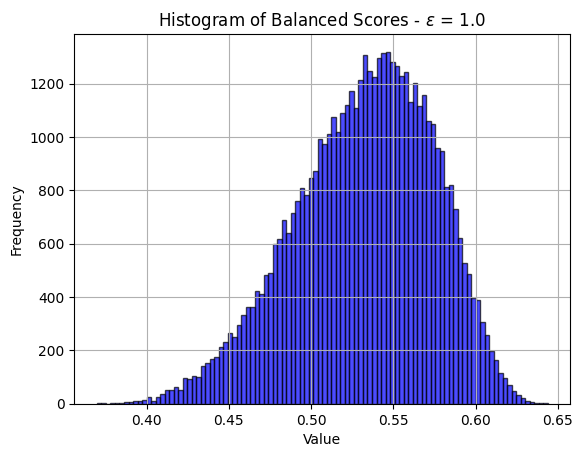

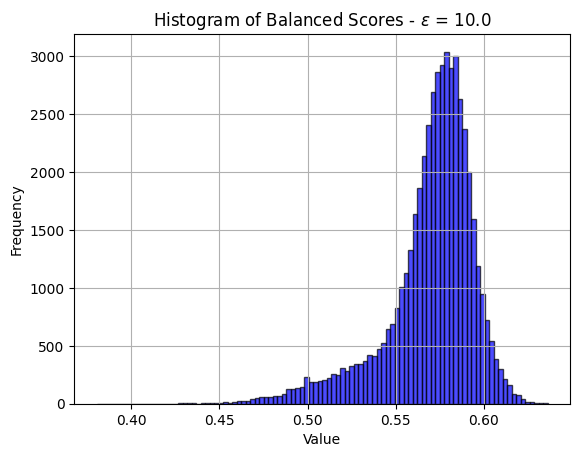

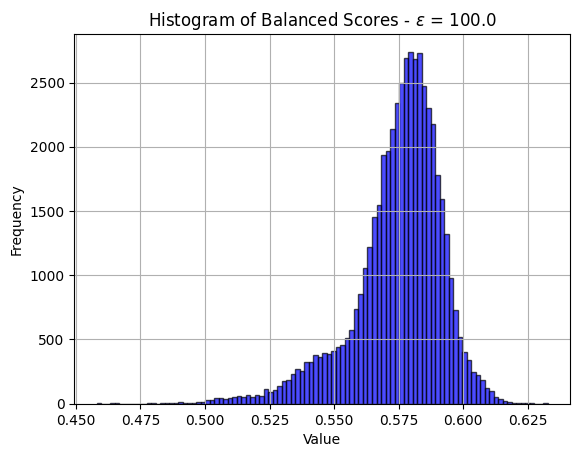

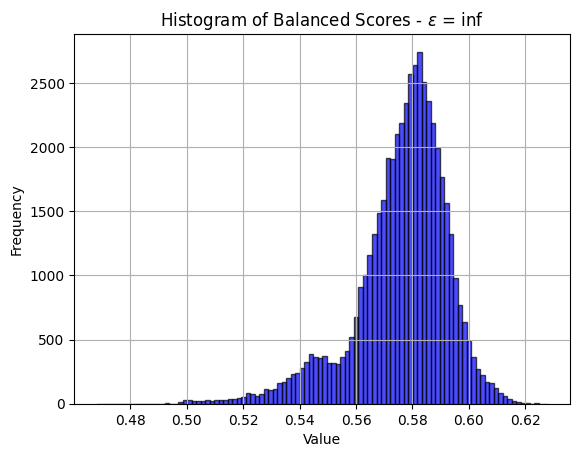

In [6]:
# Plot histogram scores
for eps in epsilon_list:
    plt.hist(all_bal_accs[eps][:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - $\epsilon$ = {eps}")
    plt.grid(True)

    # Show plot
    plt.show()

In [7]:
lower_bound = 0.5

for eps in epsilon_list:
    # idx = (all_bal_accs[eps] > lower_bound).all(dim=1)
    idx = (all_bal_accs[eps][:, -1] > lower_bound)

    all_labels[eps] = all_labels[eps][idx]
    all_params[eps] = all_params[eps][idx]
    all_bal_accs[eps] = all_bal_accs[eps][idx]
    all_auc_scores[eps] = all_auc_scores[eps][idx]

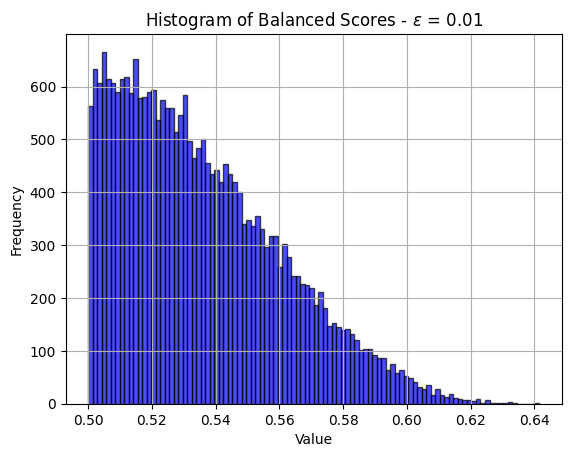

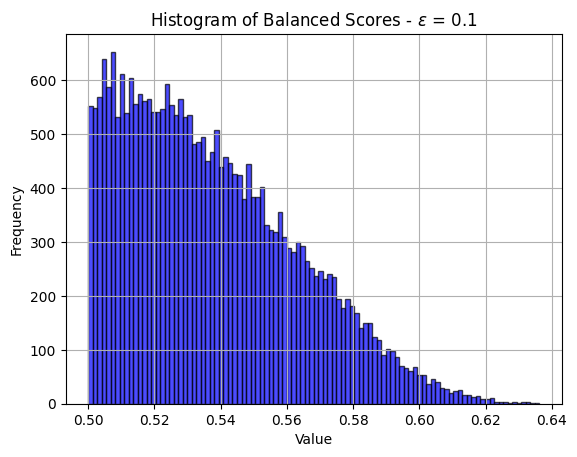

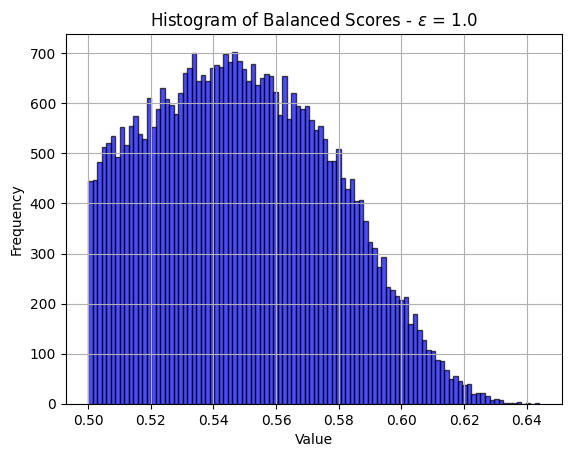

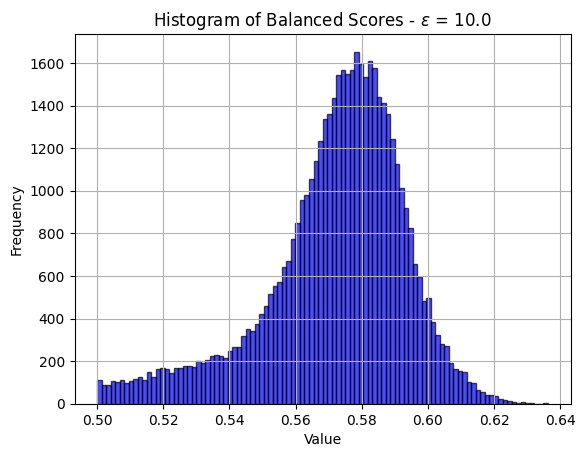

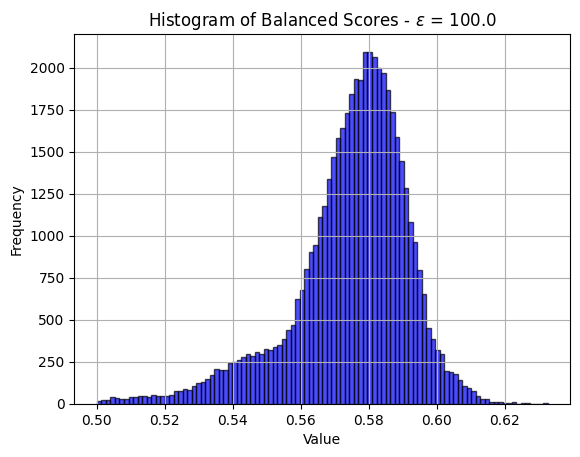

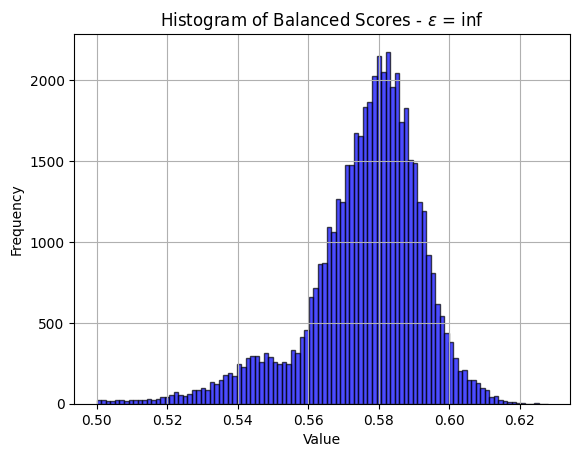

In [8]:
# Plot histogram scores
for eps in epsilon_list:
    plt.hist(all_bal_accs[eps][:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - $\epsilon$ = {eps}")
    plt.grid(True)

    # Show plot
    plt.show()

## Black-box attacks

### Weak (balanced accuracies)

In [9]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5073
F1-score: 0.5127986711529452

Confusion Matrix for Class 0 - Chowell_train:
[[0.59661551 0.40338449]
 [0.57333843 0.42666157]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.84949573 0.15050427]
 [0.84153429 0.15846571]]

Confusion Matrix for Class 2 - MSK1:
[[0.58212376 0.41787624]
 [0.540732   0.459268  ]]

Confusion Matrix for Class 3 - MSK2:
[[0.43140244 0.56859756]
 [0.4418146  0.5581854 ]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.36674437 0.63325563]
 [0.35125725 0.64874275]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.92483785 0.07516215]
 [0.93183609 0.06816391]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.18407012 0.81592988]
 [0.17751479 0.82248521]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.31276845 0.68723155]
 [0.27251732 0.72748268]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.19371118 0.80628882]
 [0.18428184 0.81571816]]


              precision    recall  f1-score   support

           0       0.52      0.43   

<IPython.core.display.Latex object>

Accuracy: 0.5140
F1-score: 0.5574808397200933

Confusion Matrix for Class 0 - Chowell_train:
[[0.33822976 0.66177024]
 [0.2886121  0.7113879 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.18296765 0.81703235]
 [0.15381844 0.84618156]]

Confusion Matrix for Class 2 - MSK1:
[[0.55656109 0.44343891]
 [0.52150729 0.47849271]]

Confusion Matrix for Class 3 - MSK2:
[[0.98940833 0.01059167]
 [0.98753209 0.01246791]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.05678922 0.94321078]
 [0.04709345 0.95290655]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.09727768 0.90272232]
 [0.09852399 0.90147601]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.60764662 0.39235338]
 [0.56910863 0.43089137]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.53414809 0.46585191]
 [0.47558703 0.52441297]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.40029059 0.59970941]
 [0.375      0.625     ]]


              precision    recall  f1-score   support

           0       0.53      0.71   

<IPython.core.display.Latex object>

...

Accuracy: 0.6724
F1-score: 0.6647008400480028

Confusion Matrix for Class 0 - Chowell_train:
[[0.73162675 0.26837325]
 [0.07264539 0.92735461]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.90405827 0.09594173]
 [0.48872911 0.51127089]]

Confusion Matrix for Class 2 - MSK1:
[[0.64351379 0.35648621]
 [0.20391614 0.79608386]]

Confusion Matrix for Class 3 - MSK2:
[[0.89261881 0.10738119]
 [0.44446664 0.55553336]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.47773938 0.52226062]
 [0.35492846 0.64507154]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63818071 0.36181929]
 [0.60003962 0.39996038]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.55686914 0.44313086]
 [0.31337958 0.68662042]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.74214606 0.25785394]
 [0.20162408 0.79837592]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.76947727 0.23052273]
 [0.56716418 0.43283582]]


              precision    recall  f1-score   support

           0       0.78      0.93   

<IPython.core.display.Latex object>

Accuracy: 0.7377
F1-score: 0.7428888699068933

Confusion Matrix for Class 0 - Chowell_train:
[[0.95275903 0.04724097]
 [0.0753292  0.9246708 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.93138224 0.06861776]
 [0.16909621 0.83090379]]

Confusion Matrix for Class 2 - MSK1:
[[0.84741091 0.15258909]
 [0.1249268  0.8750732 ]]

Confusion Matrix for Class 3 - MSK2:
[[0.33176378 0.66823622]
 [0.25994123 0.74005877]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.50254802 0.49745198]
 [0.34980392 0.65019608]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.59845941 0.40154059]
 [0.48258416 0.51741584]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.6234881  0.3765119 ]
 [0.34436564 0.65563436]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.90272602 0.09727398]
 [0.0446796  0.9553204 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.78633806 0.21366194]
 [0.34660329 0.65339671]]


              precision    recall  f1-score   support

           0       0.95      0.92   

<IPython.core.display.Latex object>

Accuracy: 0.7314
F1-score: 0.7264708163875929

Confusion Matrix for Class 0 - Chowell_train:
[[0.88649628 0.11350372]
 [0.01621828 0.98378172]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.95217562 0.04782438]
 [0.19361785 0.80638215]]

Confusion Matrix for Class 2 - MSK1:
[[0.83160165 0.16839835]
 [0.14229791 0.85770209]]

Confusion Matrix for Class 3 - MSK2:
[[0.53811659 0.46188341]
 [0.39657548 0.60342452]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.62633241 0.37366759]
 [0.46423017 0.53576983]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63423816 0.36576184]
 [0.53864033 0.46135967]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.60573547 0.39426453]
 [0.36014949 0.63985051]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91269374 0.08730626]
 [0.04967729 0.95032271]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.78463035 0.21536965]
 [0.44674556 0.55325444]]


              precision    recall  f1-score   support

           0       0.90      0.98   

### Strong (AUC scores)

In [10]:
attack_name = 'strong'

for eps in epsilon_list:
    display(Latex(f'Strong black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5097
F1-score: 0.5231871308282016

Confusion Matrix for Class 0 - Chowell_train:
[[0.37819756 0.62180244]
 [0.39152024 0.60847976]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.49844841 0.50155159]
 [0.45679969 0.54320031]]

Confusion Matrix for Class 2 - MSK1:
[[0.42169595 0.57830405]
 [0.38252656 0.61747344]]

Confusion Matrix for Class 3 - MSK2:
[[0.43254573 0.56745427]
 [0.43116371 0.56883629]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.55050505 0.44949495]
 [0.52843327 0.47156673]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.67951164 0.32048836]
 [0.67888101 0.32111899]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.37804878 0.62195122]
 [0.34990138 0.65009862]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.53143303 0.46856697]
 [0.48344881 0.51655119]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.44332298 0.55667702]
 [0.43515292 0.56484708]]


              precision    recall  f1-score   support

           0       0.50      0.61   

<IPython.core.display.Latex object>

Accuracy: 0.5158
F1-score: 0.5175236011506827

Confusion Matrix for Class 0 - Chowell_train:
[[0.13446328 0.86553672]
 [0.09964413 0.90035587]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.36147267 0.63852733]
 [0.32528818 0.67471182]]

Confusion Matrix for Class 2 - MSK1:
[[0.28733032 0.71266968]
 [0.24884465 0.75115535]]

Confusion Matrix for Class 3 - MSK2:
[[0.66617969 0.33382031]
 [0.63879721 0.36120279]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.38296323 0.61703677]
 [0.37417219 0.62582781]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.77459165 0.22540835]
 [0.78523985 0.21476015]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.74721604 0.25278396]
 [0.70371707 0.29628293]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.62077642 0.37922358]
 [0.57696608 0.42303392]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.63748638 0.36251362]
 [0.61910029 0.38089971]]


              precision    recall  f1-score   support

           0       0.52      0.90   

<IPython.core.display.Latex object>

...

Accuracy: 0.6935
F1-score: 0.7029916148228293

Confusion Matrix for Class 0 - Chowell_train:
[[0.9622213 0.0377787]
 [0.0283924 0.9716076]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.81789802 0.18210198]
 [0.05713175 0.94286825]]

Confusion Matrix for Class 2 - MSK1:
[[0.78222676 0.21777324]
 [0.31784019 0.68215981]]

Confusion Matrix for Class 3 - MSK2:
[[0.5611729  0.4388271 ]
 [0.26028765 0.73971235]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.64322017 0.35677983]
 [0.41971383 0.58028617]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.50662859 0.49337141]
 [0.37816957 0.62183043]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.61047697 0.38952303]
 [0.50148662 0.49851338]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.55732354 0.44267646]
 [0.24440483 0.75559517]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.61105548 0.38894452]
 [0.36829367 0.63170633]]


              precision    recall  f1-score   support

           0       0.96      0.97      0

<IPython.core.display.Latex object>

Accuracy: 0.7666
F1-score: 0.7648388300089966

Confusion Matrix for Class 0 - Chowell_train:
[[0.99146487 0.00853513]
 [0.00735864 0.99264136]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.87522246 0.12477754]
 [0.00194363 0.99805637]]

Confusion Matrix for Class 2 - MSK1:
[[0.80901752 0.19098248]
 [0.01424946 0.98575054]]

Confusion Matrix for Class 3 - MSK2:
[[0.86756916 0.13243084]
 [0.58237023 0.41762977]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.6127009  0.3872991 ]
 [0.16921569 0.83078431]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.71341102 0.28658898]
 [0.43471493 0.56528507]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.50663285 0.49336715]
 [0.34062254 0.65937746]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.80231418 0.19768582]
 [0.33431315 0.66568685]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.8053561  0.1946439 ]
 [0.30144583 0.69855417]]


              precision    recall  f1-score   support

           0       0.99      0.99   

<IPython.core.display.Latex object>

Accuracy: 0.7735
F1-score: 0.7801998183469573

Confusion Matrix for Class 0 - Chowell_train:
[[0.99034011 0.00965989]
 [0.0173631  0.9826369 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.96648373 0.03351627]
 [0.03602193 0.96397807]]

Confusion Matrix for Class 2 - MSK1:
[[0.89864732 0.10135268]
 [0.06791936 0.93208064]]

Confusion Matrix for Class 3 - MSK2:
[[0.46441802 0.53558198]
 [0.19779571 0.80220429]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.75523095 0.24476905]
 [0.30559876 0.69440124]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.5868833 0.4131167]
 [0.3077668 0.6922332]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.69957082 0.30042918]
 [0.52576711 0.47423289]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.71355699 0.28644301]
 [0.20614121 0.79385879]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.64435798 0.35564202]
 [0.13037475 0.86962525]]


              precision    recall  f1-score   support

           0       0.99      0.98      0

## White-box attack ensemble

In [11]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    
    X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                              f'heldout_test_set_wb_{eps}.pkl'))

    # Load models
    n_splits = 5
    loaded_models = []

    # Load each model
    for fold in range(1, n_splits + 1):
        model_path = os.path.join(attack_model_dir,
                                  f'mlp_attacker_multilabel_wb_fold_{fold}_{eps}.pkl')
        model = joblib.load(model_path)
        loaded_models.append(model)
    
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
    avg_preds = np.mean(all_preds, axis=0)
    final_preds = (avg_preds >= 0.5).astype(int)

    # Accuracy (or any other metric)
    # acc = accuracy_score(y_test, final_preds)
    # print(f"Ensemble accuracy: {acc:.4f}")
    ham = hamming_loss(y_test, final_preds)
    print(f"Ensemble accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, final_preds, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, final_preds, zero_division=0))

<IPython.core.display.Latex object>

Ensemble accuracy: 0.5143
F1-score: 0.6409921671018277

Confusion Matrix for Class 0 - Chowell_train:
[[0.08539945 0.91460055]
 [0.01680672 0.98319328]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.08145849 0.91854151]
 [0.02053468 0.97946532]]

Confusion Matrix for Class 2 - MSK1:
[[0.09702063 0.90297937]
 [0.02085793 0.97914207]]

Confusion Matrix for Class 3 - MSK2:
[[0.01943598 0.98056402]
 [0.02209073 0.97790927]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.95182595 0.04817405]
 [0.95241779 0.04758221]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.07439908 0.92560092]
 [0.03152088 0.96847912]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.04039634 0.95960366]
 [0.0382643  0.9617357 ]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.02772355 0.97227645]
 [0.03117783 0.96882217]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.07608696 0.92391304]
 [0.02206736 0.97793264]]


              precision    recall  f1-score   support

           0       0.53    

<IPython.core.display.Latex object>

Ensemble accuracy: 0.5207
F1-score: 0.647695342858851

Confusion Matrix for Class 0 - Chowell_train:
[[0.08964218 0.91035782]
 [0.01637011 0.98362989]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.06433618 0.93566382]
 [0.0129683  0.9870317 ]]

Confusion Matrix for Class 2 - MSK1:
[[0.11915535 0.88084465]
 [0.023107   0.976893  ]]

Confusion Matrix for Class 3 - MSK2:
[[0.96457268 0.03542732]
 [0.95159516 0.04840484]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.02875865 0.97124135]
 [0.02832965 0.97167035]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.07186933 0.92813067]
 [0.02435424 0.97564576]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.0237565  0.9762435 ]
 [0.02562252 0.97437748]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.01365924 0.98634076]
 [0.0152814  0.9847186 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.07192154 0.92807846]
 [0.02028024 0.97971976]]


              precision    recall  f1-score   support

           0       0.53     

<IPython.core.display.Latex object>

...

Ensemble accuracy: 0.7116
F1-score: 0.7221648597487523

Confusion Matrix for Class 0 - Chowell_train:
[[0.94715111 0.05284889]
 [0.03485412 0.96514588]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.87492196 0.12507804]
 [0.08200544 0.91799456]]

Confusion Matrix for Class 2 - MSK1:
[[0.7691522  0.2308478 ]
 [0.10126582 0.89873418]]

Confusion Matrix for Class 3 - MSK2:
[[0.7429727  0.2570273 ]
 [0.12125449 0.87874551]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.46981094 0.53018906]
 [0.34300477 0.65699523]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.51356312 0.48643688]
 [0.41105388 0.58894612]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.56889523 0.43110477]
 [0.43845391 0.56154609]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.53447572 0.46552428]
 [0.42087542 0.57912458]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.73783297 0.26216703]
 [0.40701896 0.59298104]]


              precision    recall  f1-score   support

           0       0.95    

<IPython.core.display.Latex object>

Ensemble accuracy: 0.8993
F1-score: 0.9011649032809661

Confusion Matrix for Class 0 - Chowell_train:
[[9.98213577e-01 1.78642318e-03]
 [7.74593338e-04 9.99225407e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.98773977 0.01226023]
 [0.00699708 0.99300292]]

Confusion Matrix for Class 2 - MSK1:
[[0.97617641 0.02382359]
 [0.01483506 0.98516494]]

Confusion Matrix for Class 3 - MSK2:
[[0.866392   0.133608  ]
 [0.03408423 0.96591577]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.81066249 0.18933751]
 [0.14607843 0.85392157]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.72921193 0.27078807]
 [0.21716287 0.78283713]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.7118611  0.2881389 ]
 [0.18951931 0.81048069]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91194352 0.08805648]
 [0.07858123 0.92141877]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.9477974  0.0522026 ]
 [0.06516142 0.93483858]]


              precision    recall  f1-score   support

           

<IPython.core.display.Latex object>

Ensemble accuracy: 0.9319
F1-score: 0.9322699678609689

Confusion Matrix for Class 0 - Chowell_train:
[[9.99396257e-01 6.03743208e-04]
 [1.90803282e-04 9.99809197e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99549196 0.00450804]
 [0.00665623 0.99334377]]

Confusion Matrix for Class 2 - MSK1:
[[0.99235444 0.00764556]
 [0.00763359 0.99236641]]

Confusion Matrix for Class 3 - MSK2:
[[0.9980503 0.0019497]
 [0.0051171 0.9948829]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.82787209 0.17212791]
 [0.11158631 0.88841369]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.80424014 0.19575986]
 [0.2107302  0.7892698 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.83944596 0.16055404]
 [0.17387884 0.82612116]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.9458505  0.0541495 ]
 [0.03227068 0.96772932]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96342412 0.03657588]
 [0.04457594 0.95542406]]


              precision    recall  f1-score   support

           0   

# LLR6 DP average

## Datasets

In [12]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

In [13]:
model_name = 'llr6'  # 'llr6' or 'nn2'
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'dp_datasets'

all_labels = {}
all_params = {}
all_bal_accs = {}
all_auc_scores = {}

for epsilon in epsilon_list:
    dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                               f'params_multilabel_{epsilon}.pt')

    all_labels_eps, all_params_eps, all_bal_accs_eps, all_auc_scores_eps = \
        torch.load(dataset_dir, weights_only=True)
    
    all_labels[epsilon] = all_labels_eps
    all_params[epsilon] = all_params_eps
    all_bal_accs[epsilon] = all_bal_accs_eps
    all_auc_scores[epsilon] = all_auc_scores_eps

### Accuracies on train/test

In [14]:
# Evaluate on Chowell_test
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 1]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [15]:
# Evaluate on Chowell_train
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 0]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Accuracies on all datasets

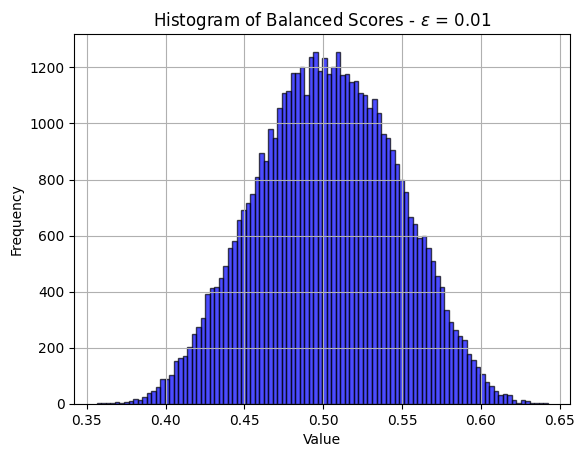

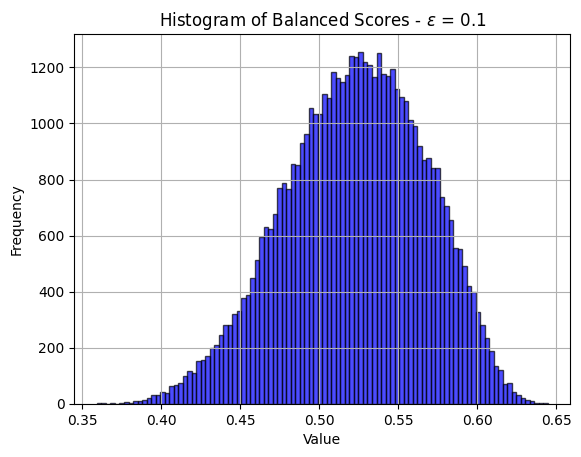

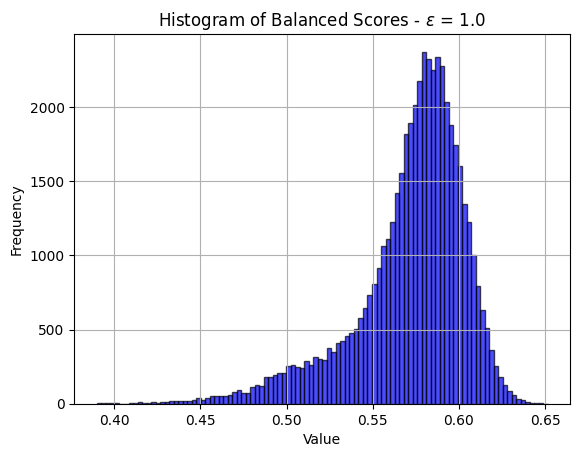

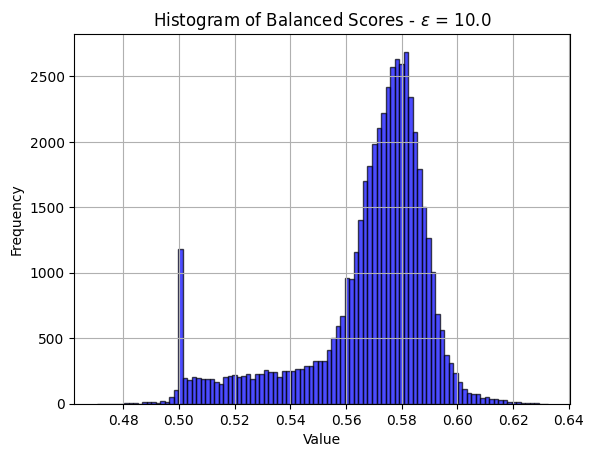

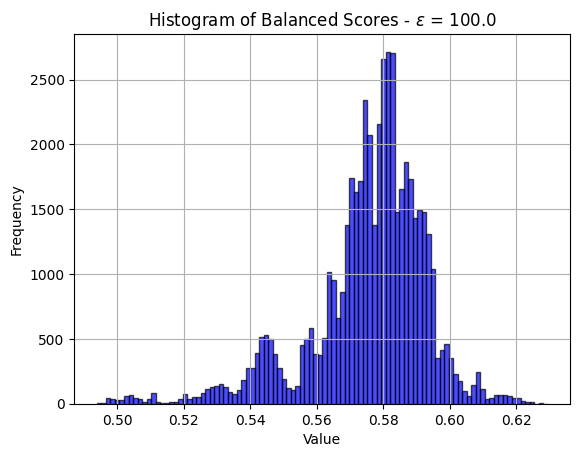

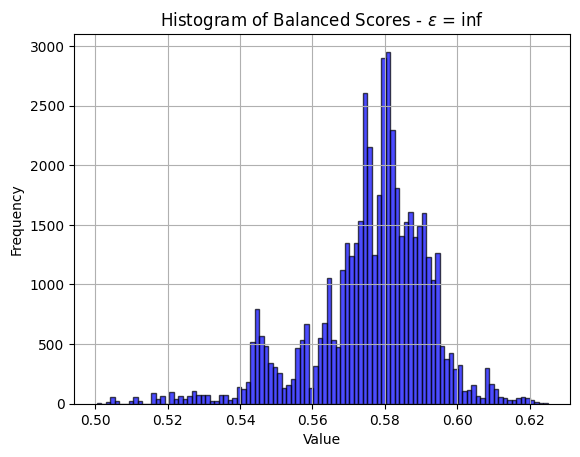

In [16]:
# Plot histogram scores
for eps in epsilon_list:
    plt.hist(all_bal_accs[eps][:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - $\epsilon$ = {eps}")
    plt.grid(True)

    # Show plot
    plt.show()

In [17]:
lower_bound = 0.5

for eps in epsilon_list:
    # idx = (all_bal_accs[eps] > lower_bound).all(dim=1)
    idx = (all_bal_accs[eps][:, -1] > lower_bound)

    all_labels[eps] = all_labels[eps][idx]
    all_params[eps] = all_params[eps][idx]
    all_bal_accs[eps] = all_bal_accs[eps][idx]
    all_auc_scores[eps] = all_auc_scores[eps][idx]

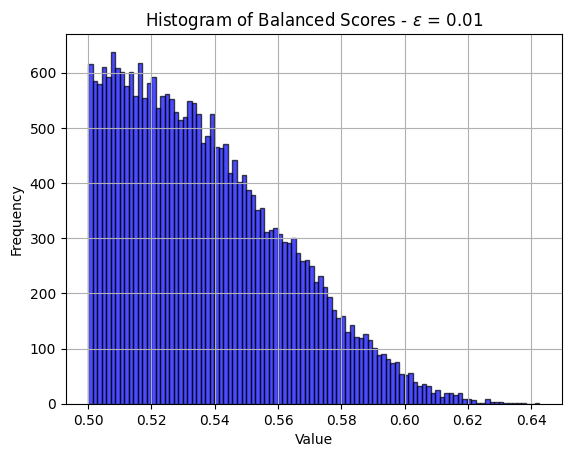

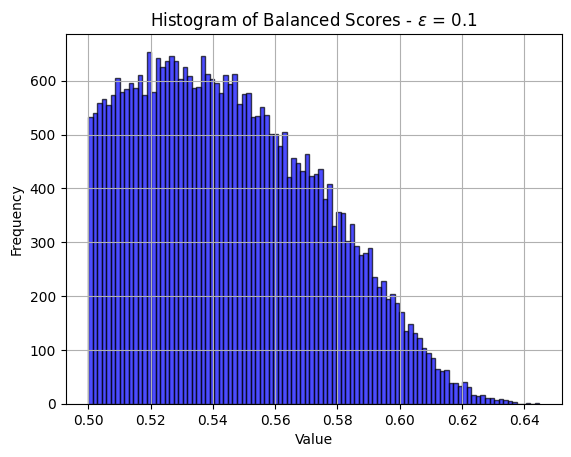

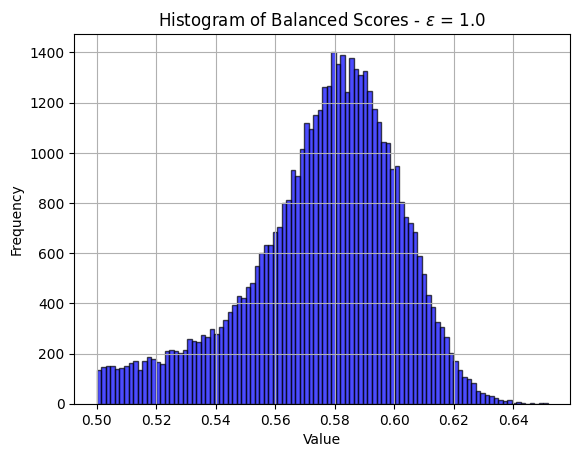

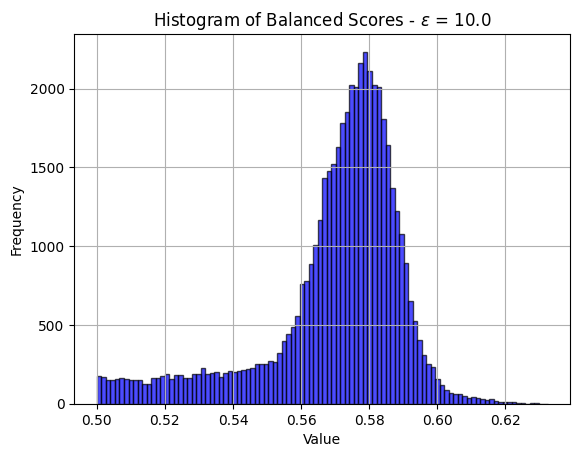

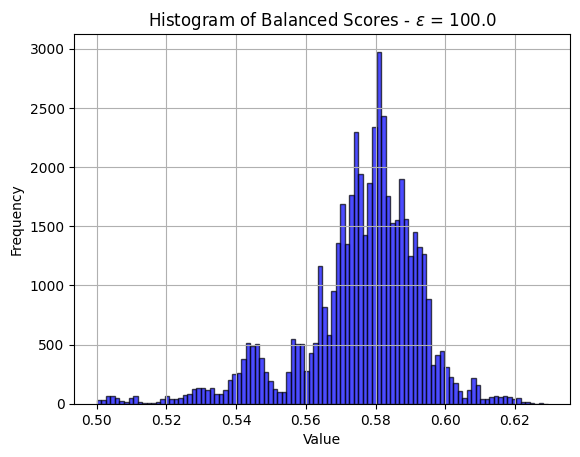

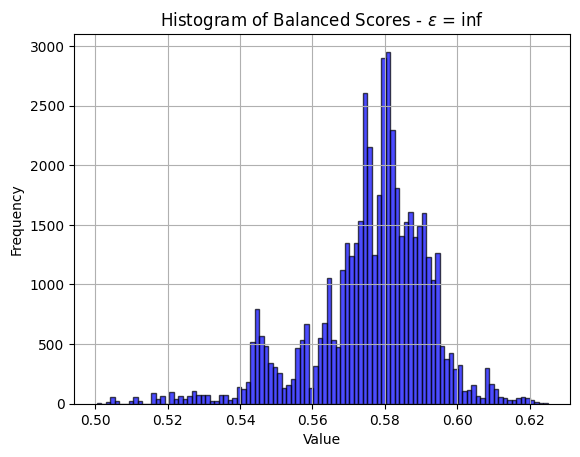

In [18]:
# Plot histogram scores
for eps in epsilon_list:
    plt.hist(all_bal_accs[eps][:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - $\epsilon$ = {eps}")
    plt.grid(True)

    # Show plot
    plt.show()

## Black-box attacks

### Weak (balanced accuracies)

In [19]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5126
F1-score: 0.5412661910096901

Confusion Matrix for Class 0 - Chowell_train:
[[0.14133739 0.85866261]
 [0.11272321 0.88727679]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.29441041 0.70558959]
 [0.28508124 0.71491876]]

Confusion Matrix for Class 2 - MSK1:
[[0.47523277 0.52476723]
 [0.43833017 0.56166983]]

Confusion Matrix for Class 3 - MSK2:
[[0.65741445 0.34258555]
 [0.65799257 0.34200743]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.56834264 0.43165736]
 [0.53510436 0.46489564]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.27375141 0.72624859]
 [0.26533685 0.73466315]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.58561259 0.41438741]
 [0.52168993 0.47831007]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.66377686 0.33622314]
 [0.63067117 0.36932883]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.39825029 0.60174971]
 [0.39873653 0.60126347]]


              precision    recall  f1-score   support

           0       0.51      0.89   

<IPython.core.display.Latex object>

Accuracy: 0.5333
F1-score: 0.5732626450780914

Confusion Matrix for Class 0 - Chowell_train:
[[0.36102133 0.63897867]
 [0.20540405 0.79459595]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.25265715 0.74734285]
 [0.19115324 0.80884676]]

Confusion Matrix for Class 2 - MSK1:
[[0.68348227 0.31651773]
 [0.65240199 0.34759801]]

Confusion Matrix for Class 3 - MSK2:
[[0.31277025 0.68722975]
 [0.27885146 0.72114854]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.52270148 0.47729852]
 [0.46677881 0.53322119]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.44903189 0.55096811]
 [0.42022911 0.57977089]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.45140449 0.54859551]
 [0.42141037 0.57858963]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.46491728 0.53508272]
 [0.3944212  0.6055788 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.55785007 0.44214993]
 [0.52362205 0.47637795]]


              precision    recall  f1-score   support

           0       0.62      0.79   

<IPython.core.display.Latex object>

...

Accuracy: 0.7497
F1-score: 0.76390509529366

Confusion Matrix for Class 0 - Chowell_train:
[[0.98137417 0.01862583]
 [0.02335539 0.97664461]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.88888889 0.11111111]
 [0.13109576 0.86890424]]

Confusion Matrix for Class 2 - MSK1:
[[0.77972388 0.22027612]
 [0.16200899 0.83799101]]

Confusion Matrix for Class 3 - MSK2:
[[0.30649087 0.69350913]
 [0.0593254  0.9406746 ]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.5278864 0.4721136]
 [0.3682254 0.6317746]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.55238475 0.44761525]
 [0.49969752 0.50030248]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.6576299  0.3423701 ]
 [0.35228387 0.64771613]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.94254788 0.05745212]
 [0.03948897 0.96051103]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.69917555 0.30082445]
 [0.21753052 0.78246948]]


              precision    recall  f1-score   support

           0       0.98      0.98      0.9

<IPython.core.display.Latex object>

Accuracy: 0.7885
F1-score: 0.78272157564906

Confusion Matrix for Class 0 - Chowell_train:
[[0.97027728 0.02972272]
 [0.         1.        ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.8955665 0.1044335]
 [0.1523308 0.8476692]]

Confusion Matrix for Class 2 - MSK1:
[[0.9154013  0.0845987 ]
 [0.00916001 0.99083999]]

Confusion Matrix for Class 3 - MSK2:
[[0.767428   0.232572  ]
 [0.52467583 0.47532417]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.72700644 0.27299356]
 [0.49616217 0.50383783]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.44376238 0.55623762]
 [0.3736413  0.6263587 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.75137363 0.24862637]
 [0.22013318 0.77986682]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.98467967 0.01532033]
 [0.00869397 0.99130603]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.92482077 0.07517923]
 [0.4054751  0.5945249 ]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.9

<IPython.core.display.Latex object>

Accuracy: 0.8002
F1-score: 0.8057745556001775

Confusion Matrix for Class 0 - Chowell_train:
[[9.86880752e-01 1.31192481e-02]
 [1.95579894e-04 9.99804420e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.89529412 0.10470588]
 [0.16132812 0.83867187]]

Confusion Matrix for Class 2 - MSK1:
[[0.95627451 0.04372549]
 [0.00175781 0.99824219]]

Confusion Matrix for Class 3 - MSK2:
[[0.55695711 0.44304289]
 [0.36076574 0.63923426]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.61539973 0.38460027]
 [0.37278222 0.62721778]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.2498528 0.7501472]
 [0.1715122 0.8284878]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.78176088 0.21823912]
 [0.12657982 0.87342018]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.99217374 0.00782626]
 [0.00567626 0.99432374]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.90401699 0.09598301]
 [0.33934946 0.66065054]]


              precision    recall  f1-score   support

           0       0.99 

### Strong (AUC scores)

In [20]:
attack_name = 'strong'

for eps in epsilon_list:
    display(Latex(f'Strong black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5093
F1-score: 0.5330073349633252

Confusion Matrix for Class 0 - Chowell_train:
[[0.10790274 0.89209726]
 [0.09040179 0.90959821]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.19257274 0.80742726]
 [0.16654357 0.83345643]]

Confusion Matrix for Class 2 - MSK1:
[[0.31247672 0.68752328]
 [0.26413662 0.73586338]]

Confusion Matrix for Class 3 - MSK2:
[[0.61787072 0.38212928]
 [0.61821561 0.38178439]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.57802607 0.42197393]
 [0.56698292 0.43301708]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63086744 0.36913256]
 [0.62100113 0.37899887]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.45185463 0.54814537]
 [0.42889476 0.57110524]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.60082925 0.39917075]
 [0.58192726 0.41807274]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.64549258 0.35450742]
 [0.64251208 0.35748792]]


              precision    recall  f1-score   support

           0       0.51      0.91   

<IPython.core.display.Latex object>

Accuracy: 0.5334
F1-score: 0.6043291653932524

Confusion Matrix for Class 0 - Chowell_train:
[[0.24725275 0.75274725]
 [0.13009757 0.86990243]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.33404191 0.66595809]
 [0.23933649 0.76066351]]

Confusion Matrix for Class 2 - MSK1:
[[0.21620063 0.78379937]
 [0.16316952 0.83683048]]

Confusion Matrix for Class 3 - MSK2:
[[0.22946094 0.77053906]
 [0.21120928 0.78879072]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.30363224 0.69636776]
 [0.26745164 0.73254836]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.37841686 0.62158314]
 [0.37468567 0.62531433]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.31207865 0.68792135]
 [0.27046163 0.72953837]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.69423845 0.30576155]
 [0.62733612 0.37266388]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.55077793 0.44922207]
 [0.51546682 0.48453318]]


              precision    recall  f1-score   support

           0       0.60      0.87   

<IPython.core.display.Latex object>

...

Accuracy: 0.7930
F1-score: 0.7956736059152326

Confusion Matrix for Class 0 - Chowell_train:
[[9.95860927e-01 4.13907285e-03]
 [7.78513040e-04 9.99221487e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.95840979 0.04159021]
 [0.0213228  0.9786772 ]]

Confusion Matrix for Class 2 - MSK1:
[[0.91469194 0.08530806]
 [0.05550127 0.94449873]]

Confusion Matrix for Class 3 - MSK2:
[[0.60730223 0.39269777]
 [0.34285714 0.65714286]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.82877135 0.17122865]
 [0.19722168 0.80277832]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.77888645 0.22111355]
 [0.48336358 0.51663642]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.54179503 0.45820497]
 [0.31346795 0.68653205]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.72793505 0.27206495]
 [0.17402245 0.82597755]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.80273477 0.19726523]
 [0.30218131 0.69781869]]


              precision    recall  f1-score   support

           0       1

<IPython.core.display.Latex object>

Accuracy: 0.8169
F1-score: 0.822625742532471

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.96669951 0.03330049]
 [0.         1.        ]]

Confusion Matrix for Class 2 - MSK1:
[[0.97889963 0.02110037]
 [0.01715065 0.98284935]]

Confusion Matrix for Class 3 - MSK2:
[[0.53584906 0.46415094]
 [0.18560093 0.81439907]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.86115993 0.13884007]
 [0.23951978 0.76048022]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.72811881 0.27188119]
 [0.28746118 0.71253882]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.46762166 0.53237834]
 [0.33215825 0.66784175]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.79446876 0.20553124]
 [0.1572643  0.8427357 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.77116838 0.22883162]
 [0.18488395 0.81511605]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5189
           1   

<IPython.core.display.Latex object>

Accuracy: 0.8248
F1-score: 0.831956784716139

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.99411765e-01 5.88235294e-04]
 [0.00000000e+00 1.00000000e+00]]

Confusion Matrix for Class 2 - MSK1:
[[0.91294118 0.08705882]
 [0.03535156 0.96464844]]

Confusion Matrix for Class 3 - MSK2:
[[0.64506113 0.35493887]
 [0.24176041 0.75823959]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.83637792 0.16362208]
 [0.11932151 0.88067849]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63002944 0.36997056]
 [0.14673171 0.85326829]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.46681111 0.53318889]
 [0.27824227 0.72175773]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.77988652 0.22011348]
 [0.19808182 0.80191818]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.76651217 0.23348783]
 [0.17175724 0.82824276]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5113

## White-box attack ensemble

In [21]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    
    X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                              f'heldout_test_set_wb_{eps}.pkl'))

    # Load models
    n_splits = 5
    loaded_models = []

    # Load each model
    for fold in range(1, n_splits + 1):
        model_path = os.path.join(attack_model_dir,
                                  f'mlp_attacker_multilabel_wb_fold_{fold}_{eps}.pkl')
        model = joblib.load(model_path)
        loaded_models.append(model)
    
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
    avg_preds = np.mean(all_preds, axis=0)
    final_preds = (avg_preds >= 0.5).astype(int)

    # Accuracy (or any other metric)
    # acc = accuracy_score(y_test, final_preds)
    # print(f"Ensemble accuracy: {acc:.4f}")
    ham = hamming_loss(y_test, final_preds)
    print(f"Ensemble accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, final_preds, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, final_preds, zero_division=0))

<IPython.core.display.Latex object>

Ensemble accuracy: 0.6151
F1-score: 0.6177208887413647

Confusion Matrix for Class 0 - Chowell_train:
[[0.68085106 0.31914894]
 [0.1469494  0.8530506 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.64127106 0.35872894]
 [0.14918759 0.85081241]]

Confusion Matrix for Class 2 - MSK1:
[[0.63612663 0.36387337]
 [0.20531309 0.79468691]]

Confusion Matrix for Class 3 - MSK2:
[[0.60228137 0.39771863]
 [0.53754647 0.46245353]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.61862197 0.38137803]
 [0.57267552 0.42732448]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.60833646 0.39166354]
 [0.46782085 0.53217915]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.58448857 0.41551143]
 [0.4696341  0.5303659 ]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.58424425 0.41575575]
 [0.43344582 0.56655418]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.53822746 0.46177254]
 [0.44407284 0.55592716]]


              precision    recall  f1-score   support

           0       0.73    

<IPython.core.display.Latex object>

Ensemble accuracy: 0.6242
F1-score: 0.652366735267689

Confusion Matrix for Class 0 - Chowell_train:
[[0.6719457  0.3280543 ]
 [0.11233425 0.88766575]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.60279381 0.39720619]
 [0.13059505 0.86940495]]

Confusion Matrix for Class 2 - MSK1:
[[0.63217065 0.36782935]
 [0.18498067 0.81501933]]

Confusion Matrix for Class 3 - MSK2:
[[0.53588931 0.46411069]
 [0.47625621 0.52374379]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.50908059 0.49091941]
 [0.41883936 0.58116064]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.42625285 0.57374715]
 [0.26683431 0.73316569]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.56994382 0.43005618]
 [0.4420844  0.5579156 ]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.59412436 0.40587564]
 [0.4097629  0.5902371 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.51145686 0.48854314]
 [0.43082115 0.56917885]]


              precision    recall  f1-score   support

           0       0.78     

<IPython.core.display.Latex object>

...

Ensemble accuracy: 0.9197
F1-score: 0.9225745467044771

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99714577 0.00285423]
 [0.00217177 0.99782823]]

Confusion Matrix for Class 2 - MSK1:
[[0.99320008 0.00679992]
 [0.00644909 0.99355091]]

Confusion Matrix for Class 3 - MSK2:
[[0.67728195 0.32271805]
 [0.1140873  0.8859127 ]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.89092406 0.10907594]
 [0.06124046 0.93875954]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.80961884 0.19038116]
 [0.12502521 0.87497479]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.80406654 0.19593346]
 [0.16800627 0.83199373]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.9429642 0.0570358]
 [0.0414247 0.9585753]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.97828273 0.02171727]
 [0.02541525 0.97458475]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5138
         

<IPython.core.display.Latex object>

Ensemble accuracy: 0.9986
F1-score: 0.9985608708354523

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[9.83515392e-01 1.64846077e-02]
 [5.80607703e-04 9.99419392e-01]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[9.99023628e-01 9.76371802e-04]
 [3.93623302e-04 9.99606377e-01]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.99861386 0.00138614]
 [0.00194099 0.99805901]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.99882261 0.00117739]
 [0.00235018 0.99764982]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[9.99403104e-01 5.96896140e-04]
 [0.00000000e+00 1.00000000e+00]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[9.99806239e-01 1.93760899e-04]
 [1.98373339e-04 9.99801627e-01]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5189
     

<IPython.core.display.Latex object>

Ensemble accuracy: 1.0000
F1-score: 0.9999564933652382

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[9.99411187e-01 5.88812561e-04]
 [0.00000000e+00 1.00000000e+00]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[9.99803033e-01 1.96966713e-04]
 [0.00000000e+00 1.00000000e+00]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[1. 0.]
 [0. 1.]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5113
           1       1.00      1.00      1.00      5120
           2       1.00      1.00      1.00      5120
           3       1.00      1.00      1.00      5067
   